In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import warnings
import json
import os
from typing import Dict, List, Tuple

from gymnasium import spaces
from stable_baselines3 import PPO, SAC
from stable_baselines3.common.callbacks import BaseCallback
from sklearn.preprocessing import StandardScaler

from utile import *
from super_agent_env import SuperAgentEnv, train_super_agent_sac
from meta_agent_env import MetaAgentEnv, train_meta_agent
from production_agent_wrapper_frozen import ProductionAgentWrapper

sns.set_style("darkgrid")
warnings.filterwarnings('ignore')

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:

OPTIMAL_CONFIG = {
    # Data Splitting
    'use_walk_forward': True,
    'walk_forward_windows': 5,
    'min_train_months': 60,
    
    # Fallback
    'train_ratio': 0.70,
    'val_ratio': 0.15,
    'test_ratio': 0.15,
    
    # SUPER AGENT (Now with SAC)
    'super_learning_rate': 0.001,      # SAC typically needs higher LR
    'super_timesteps': 100_000,
    'super_network': [256, 128],        # Larger network for more features
    'super_batch_size': 256,
    'super_buffer_size': 50_000,        # SAC replay buffer
    'super_tau': 0.005,                 # SAC soft update
    'super_gamma': 0.98,
    'super_ent_coef': 'auto',           # SAC auto entropy tuning
    'super_eval_freq': 2_000,
    'super_patience': 10,
    'super_min_delta': 0.01,
    
    # META AGENT (Stays PPO)
    'meta_learning_rate': 0.0001,
    'meta_timesteps': 50_000,
    'meta_network': [64, 32],
    'meta_batch_size': 256,
    'meta_n_steps': 2048,
    'meta_n_epochs': 3,
    'meta_gamma': 0.98,
    'meta_ent_coef': 0.005,
    'meta_max_grad_norm': 0.5,
    'meta_gae_lambda': 0.95,
    'meta_eval_freq': 2_000,
    'meta_patience': 10,
    'meta_min_delta': 0.005,
    
    # Risk Constraints
    'max_position': 0.30,
    'min_position': 0.05,
    'max_turnover': 0.50,
    'min_market_exposure': 0.90,
    'transaction_cost': 0.002,
    
    # Reward Function
    'alpha_returns': 3.0,
    'alpha_mdd': 1.0,
    'alpha_vol': 0.5,
    'alpha_concentration': 0.3,
    'exploration_bias': 0.01,
    'constraint_penalty': 50.0,
    
    # Training Stability
    'seed': 42,
    'min_training_episodes': 5,
    'verbose': 1,
}


## HIERARCHICAL TRADING SYSTEM - STANDARD SPLIT

**Architecture:**
- **Base:** 4 agents (tech_PPO, tech_SAC, sent_PPO, sent_SAC)
- **Super:** SAC with enhanced observations
- **Meta:** PPO adjusting for regimes


In [3]:
# Load data
print("\n[1/6] Loading data...")
price_data = pd.read_csv('data/price_data.csv', index_col=0, parse_dates=True)
technical_features = pd.read_csv('data/technical_features.csv', index_col=0, parse_dates=True)
sentiment_features = pd.read_csv('data/sentiment_features.csv', index_col=0, parse_dates=True)
regime = pd.read_csv('data/regime_indicators.csv', index_col=0, parse_dates=True)
qqq_benchmark = pd.read_csv('data/qqq_benchmark.csv', index_col=0, parse_dates=True)

print(f"\n   Trading data: {price_data.shape}")
print(f"   Assets: {list(price_data.columns)}")


[1/6] Loading data...

   Trading data: (129, 10)
   Assets: ['NVDA', 'MU', 'MRVL', 'MSFT', 'ASML', 'AEM', 'AMD', 'GOOGL', 'PLUG', 'INGN']


#### **Data Split:** 70% Train / 20% Validation / 10% Test

In [4]:

print("\n[2/6] Creating train/val/test splits...")
train_data, val_data, test_data = create_train_val_test_split(price_data, technical_features, sentiment_features, regime)
test_prices, test_tech, test_sent, test_regime = test_data


[2/6] Creating train/val/test splits...

DATA SPLIT: 70% TRAIN / 20% VALIDATION / 10% TEST

Total data: 129 months
Date range: 2015-02 to 2025-10

Train Set (70%):
  Dates: 2015-02 to 2022-07
  Size:  90 months

Validation Set (20%):
  Dates: 2022-08 to 2024-09
  Size:  26 months

Test Set (10%):
  Dates: 2024-10 to 2025-10
  Size:  13 months

Data split created successfully!


In [5]:
# QQQ baseline
print("\n[3/6] Calculating QQQ baseline...")
test_qqq = qqq_benchmark.loc[test_prices.index]
qqq_returns = test_qqq['QQQ'].pct_change().dropna()
qqq_total_return = (test_qqq['QQQ'].iloc[-1] / test_qqq['QQQ'].iloc[0]) - 1
qqq_total_return -= 2 * OPTIMAL_CONFIG['transaction_cost']

qqq_sharpe = qqq_returns.mean() / qqq_returns.std() * np.sqrt(12) if len(qqq_returns) > 0 else 0.0

cumulative = (1 + qqq_returns).cumprod()
running_max = cumulative.expanding().max()
drawdown = (cumulative - running_max) / running_max
qqq_max_dd = abs(drawdown.min())

qqq_metrics = {
    'strategy': 'QQQ Buy & Hold',
    'total_return': qqq_total_return,
    'sharpe_ratio': qqq_sharpe,
    'max_drawdown': qqq_max_dd,
    'volatility': qqq_returns.std() * np.sqrt(12),
    'win_rate': (qqq_returns > 0).sum() / len(qqq_returns),
    'final_value': 100_000 * (1 + qqq_total_return)
}

print(f"\n   QQQ Baseline: Sharpe={qqq_sharpe:.3f}, Return={qqq_total_return*100:.1f}%")



[3/6] Calculating QQQ baseline...

   QQQ Baseline: Sharpe=1.338, Return=21.4%


In [6]:
# Train Enhanced Super agent
print("\n[4/6] Training Enhanced Super agent...")
super_model, super_val_sharpe = train_super_agent_sac(train_data, val_data, OPTIMAL_CONFIG)

os.makedirs('models', exist_ok=True)
super_model.save('models/super_agent_sac_best.zip')
print(f"\n   ✓ Saved: models/super_agent_sac_best.zip")



[4/6] Training Enhanced Super agent...

TRAINING ENHANCED SUPER AGENT (SAC + FULL FEATURES)

   Loading base agents...

   Creating environments...
   Super Agent observation size: 203
      - Base weights: 40
      - Technical:    110
      - Sentiment:    53
   Super Agent observation size: 203
      - Base weights: 40
      - Technical:    110
      - Sentiment:    53

   Training with SAC algorithm...

   Training for up to 100000 steps...
  Step 10000: Val Sharpe = 0.897
New best! (Sharpe: 0.897)
  Step 12000: Val Sharpe = 0.890
No improvement (1/10)
  Step 14000: Val Sharpe = 0.949
New best! (Sharpe: 0.949)
  Step 16000: Val Sharpe = 0.929
No improvement (1/10)
  Step 18000: Val Sharpe = 0.842
No improvement (2/10)
  Step 20000: Val Sharpe = 0.788
No improvement (3/10)
  Step 22000: Val Sharpe = 0.872
No improvement (4/10)
  Step 24000: Val Sharpe = 0.884
No improvement (5/10)
  Step 26000: Val Sharpe = 0.865
No improvement (6/10)
  Step 28000: Val Sharpe = 0.843
No improvement 

In [7]:
# Train Meta agent
print("\n[5/6] Training Meta agent...")
meta_model, meta_val_sharpe = train_meta_agent(train_data, val_data, super_model, OPTIMAL_CONFIG)

meta_model.save('models/meta_agent_best.zip')
print(f"\n   ✓ Saved: models/meta_agent_best.zip")


[5/6] Training Meta agent...

TRAINING META AGENT

   Loading base agents...

   Creating Super agent environments...
   Super Agent observation size: 203
      - Base weights: 40
      - Technical:    110
      - Sentiment:    53
   Super Agent observation size: 203
      - Base weights: 40
      - Technical:    110
      - Sentiment:    53
   Creating Meta agent environments...

   Training with PPO algorithm...

   Training for up to 50000 steps...
  Step 10000: Val Sharpe = 0.709
New best! (Sharpe: 0.709)
  Step 12000: Val Sharpe = 0.632
No improvement (1/10)
  Step 14000: Val Sharpe = 0.670
No improvement (2/10)
  Step 16000: Val Sharpe = 0.674
No improvement (3/10)
  Step 18000: Val Sharpe = 0.681
No improvement (4/10)
  Step 20000: Val Sharpe = 0.671
No improvement (5/10)
  Step 22000: Val Sharpe = 0.711
No improvement (6/10)
  Step 24000: Val Sharpe = 0.717
New best! (Sharpe: 0.717)
  Step 26000: Val Sharpe = 0.748
New best! (Sharpe: 0.748)
  Step 28000: Val Sharpe = 0.753
New

In [8]:
# Final evaluation (unchanged)
print("\n[6/6] Final evaluation on test set...")

n_assets = len(test_prices.columns)

# Load base agents
print(f"\n   Loading base agents...")
tech_ppo_model = PPO.load('models/best_technical_PPO.zip')
tech_sac_model = SAC.load('models/best_technical_SAC.zip')
sent_ppo_model = PPO.load('models/best_sentiment_PPO.zip')
sent_sac_model = SAC.load('models/best_sentiment_SAC.zip')

base_agents_test = {
    'tech_PPO': ProductionAgentWrapper(tech_ppo_model, test_tech, n_assets, 'tech_PPO'),
    'tech_SAC': ProductionAgentWrapper(tech_sac_model, test_tech, n_assets, 'tech_SAC'),
    'sent_PPO': ProductionAgentWrapper(sent_ppo_model, test_sent, n_assets, 'sent_PPO'),
    'sent_SAC': ProductionAgentWrapper(sent_sac_model, test_sent, n_assets, 'sent_SAC'),
}

# Evaluate Super
print(f"\n   Evaluating Enhanced Super agent...")
super_test_env = SuperAgentEnv(
    test_prices, 
    base_agents_test, 
    test_tech, 
    test_sent, 
    **OPTIMAL_CONFIG
)
obs, _ = super_test_env.reset()
done = False
while not done:
    action, _ = super_model.predict(obs, deterministic=True)
    obs, _, done, _, _ = super_test_env.step(action)
super_metrics = super_test_env.get_portfolio_metrics()
super_metrics['strategy'] = 'Enhanced Super (SAC+Full)'
super_portfolio_history = super_test_env.portfolio_history.copy()
super_final_weights = super_test_env.weights.copy()

# Evaluate Meta
print(f"   Evaluating Meta agent...")
super_test_wrap = ProductionAgentWrapper(super_model, super_test_env, n_assets, 'super')
meta_test_env = MetaAgentEnv(test_prices, super_test_wrap, test_regime, **OPTIMAL_CONFIG)
obs, _ = meta_test_env.reset()
done = False
while not done:
    action, _ = meta_model.predict(obs, deterministic=True)
    obs, _, done, _, _ = meta_test_env.step(action)
meta_metrics = meta_test_env.get_portfolio_metrics()
meta_metrics['strategy'] = 'Meta Agent'
meta_portfolio_history = meta_test_env.portfolio_history.copy()
meta_final_weights = meta_test_env.weights.copy()

# Best base agent
print(f"   Evaluating best base agent...")
best_base_env = SuperAgentEnv(
    test_prices, {'sent_PPO': base_agents_test['sent_PPO']}, 
    test_tech, test_sent, **OPTIMAL_CONFIG
)
obs, _ = best_base_env.reset()
done = False
while not done:
    action = base_agents_test['sent_PPO'].weights
    obs, _, done, _, _ = best_base_env.step(action)
best_base_metrics = best_base_env.get_portfolio_metrics()
best_base_metrics['strategy'] = 'Best Base (sent_PPO)'
best_base_portfolio_history = best_base_env.portfolio_history.copy()
best_base_final_weights = best_base_env.weights.copy()

# QQQ portfolio history for visualization
qqq_portfolio_history = (test_qqq['QQQ'] / test_qqq['QQQ'].iloc[0] * 100_000).tolist()

# Results (unchanged)
print("\n" + "="*70)
print("RESULTS")
print("="*70)

print(f"\nEnhanced Super Agent:")
print(f"  Val Sharpe:      {super_val_sharpe:.3f}")
print(f"  Test Sharpe:     {super_metrics['sharpe_ratio']:.3f}")
print(f"  Val/Test Ratio:  {super_metrics['sharpe_ratio']/super_val_sharpe:.2f}x")

print(f"\nMeta Agent:")
print(f"  Val Sharpe:      {meta_val_sharpe:.3f}")
print(f"  Test Sharpe:     {meta_metrics['sharpe_ratio']:.3f}")
print(f"  Val/Test Ratio:  {meta_metrics['sharpe_ratio']/meta_val_sharpe:.2f}x")

# Comparison table
print("\n" + "="*70)
print("FINAL COMPARISON (Test Set)")
print("="*70)


[6/6] Final evaluation on test set...

   Loading base agents...

   Evaluating Enhanced Super agent...
   Super Agent observation size: 203
      - Base weights: 40
      - Technical:    110
      - Sentiment:    53
   Evaluating Meta agent...
   Evaluating best base agent...
   Super Agent observation size: 173
      - Base weights: 10
      - Technical:    110
      - Sentiment:    53

RESULTS

Enhanced Super Agent:
  Val Sharpe:      0.949
  Test Sharpe:     1.601
  Val/Test Ratio:  1.69x

Meta Agent:
  Val Sharpe:      0.853
  Test Sharpe:     1.999
  Val/Test Ratio:  2.34x

FINAL COMPARISON (Test Set)


In [9]:
all_strategies = [qqq_metrics, best_base_metrics, super_metrics, meta_metrics]

print(f"\n{'Strategy':<30s} {'Sharpe':>10s} {'Return':>10s} {'Max DD':>10s} {'Win Rate':>10s}")
print("-"*70)

for metrics in all_strategies:
    print(f"{metrics['strategy']:<30s} "
            f"{metrics['sharpe_ratio']:>10.3f} "
            f"{metrics['total_return']*100:>9.1f}% "
            f"{metrics['max_drawdown']*100:>9.1f}% "
            f"{metrics['win_rate']*100:>9.1f}%")

# Performance vs QQQ
print("\n" + "="*70)
print("PERFORMANCE vs QQQ")
print("="*70)

baseline_sharpe = qqq_metrics['sharpe_ratio']

strategies_to_compare = [
    ('Best Base Agent', best_base_metrics),
    ('Enhanced Super Agent', super_metrics),
    ('Meta Agent', meta_metrics)
]

print(f"\n{'Strategy':<30s} {'vs QQQ':>12s} {'Assessment':>20s}")
print("-"*70)

for name, metrics in strategies_to_compare:
    improvement = ((metrics['sharpe_ratio'] - baseline_sharpe) / baseline_sharpe * 100) if baseline_sharpe > 0 else 0
    
    if improvement > 20:
        assessment = "Excellent"
    elif improvement > 5:
        assessment = "Good"
    elif improvement > -5:
        assessment = "Comparable"
    else:
        assessment = "Underperforms"
    
    print(f"{name:<30s} {improvement:>11.1f}% {assessment:>20s}")



Strategy                           Sharpe     Return     Max DD   Win Rate
----------------------------------------------------------------------
QQQ Buy & Hold                      1.338      21.4%      10.2%      75.0%
Best Base (sent_PPO)                1.577      54.7%      18.8%      66.7%
Enhanced Super (SAC+Full)           1.601      57.1%      19.2%      66.7%
Meta Agent                          1.999      77.9%      15.1%      66.7%

PERFORMANCE vs QQQ

Strategy                             vs QQQ           Assessment
----------------------------------------------------------------------
Best Base Agent                       17.8%                 Good
Enhanced Super Agent                  19.6%                 Good
Meta Agent                            49.4%            Excellent


In [10]:

# Diagnostics
print("\n" + "="*70)
print("DIAGNOSTICS")
print("="*70)

print(f"\n1. Generalization:")
print(f"   Super Val/Test:  {super_metrics['sharpe_ratio']/super_val_sharpe:.2f}x")
print(f"   Meta Val/Test:   {meta_metrics['sharpe_ratio']/meta_val_sharpe:.2f}x")
print(f"   (Ratios close to 1.0 indicate good generalization)")

print(f"\n2. Hierarchy Value:")
print(f"   Base → Super: {best_base_metrics['sharpe_ratio']:.3f} → {super_metrics['sharpe_ratio']:.3f} "
        f"({(super_metrics['sharpe_ratio']/best_base_metrics['sharpe_ratio']-1)*100:+.1f}%)")
print(f"   Super → Meta: {super_metrics['sharpe_ratio']:.3f} → {meta_metrics['sharpe_ratio']:.3f} "
        f"({(meta_metrics['sharpe_ratio']/super_metrics['sharpe_ratio']-1)*100:+.1f}%)")

# Recommendation
sharpes = {
    'QQQ': qqq_metrics['sharpe_ratio'],
    'Best Base': best_base_metrics['sharpe_ratio'],
    'Enhanced Super': super_metrics['sharpe_ratio'],
    'Meta': meta_metrics['sharpe_ratio']
}

best_strategy = max(sharpes, key=sharpes.get)
best_sharpe = sharpes[best_strategy]

print(f"\n3. Deployment Recommendation:")
print(f"   🏆 Best performer: {best_strategy} (Sharpe: {best_sharpe:.3f})")

# Save results
results = {
    'qqq_baseline': {k: float(v) if isinstance(v, (np.floating, float)) else v 
                    for k, v in qqq_metrics.items()},
    'best_base_agent': {k: float(v) if isinstance(v, (np.floating, float)) else v 
                        for k, v in best_base_metrics.items()},
    'enhanced_super_agent': {
        'val_sharpe': float(super_val_sharpe),
        'test_metrics': {k: float(v) if isinstance(v, (np.floating, float)) else v 
                        for k, v in super_metrics.items()}
    },
    'meta_agent': {
        'val_sharpe': float(meta_val_sharpe),
        'test_metrics': {k: float(v) if isinstance(v, (np.floating, float)) else v 
                        for k, v in meta_metrics.items()}
    },
    'best_strategy': best_strategy,
    'split': '70_20_10'
}

os.makedirs('results', exist_ok=True)
with open('results/standard_split_results.json', 'w') as f:
    json.dump(results, f, indent=2)




DIAGNOSTICS

1. Generalization:
   Super Val/Test:  1.69x
   Meta Val/Test:   2.34x
   (Ratios close to 1.0 indicate good generalization)

2. Hierarchy Value:
   Base → Super: 1.577 → 1.601 (+1.5%)
   Super → Meta: 1.601 → 1.999 (+24.9%)

3. Deployment Recommendation:
   🏆 Best performer: Meta (Sharpe: 1.999)



   Creating performance comparison plot...
Saved: results/performance_comparison.png


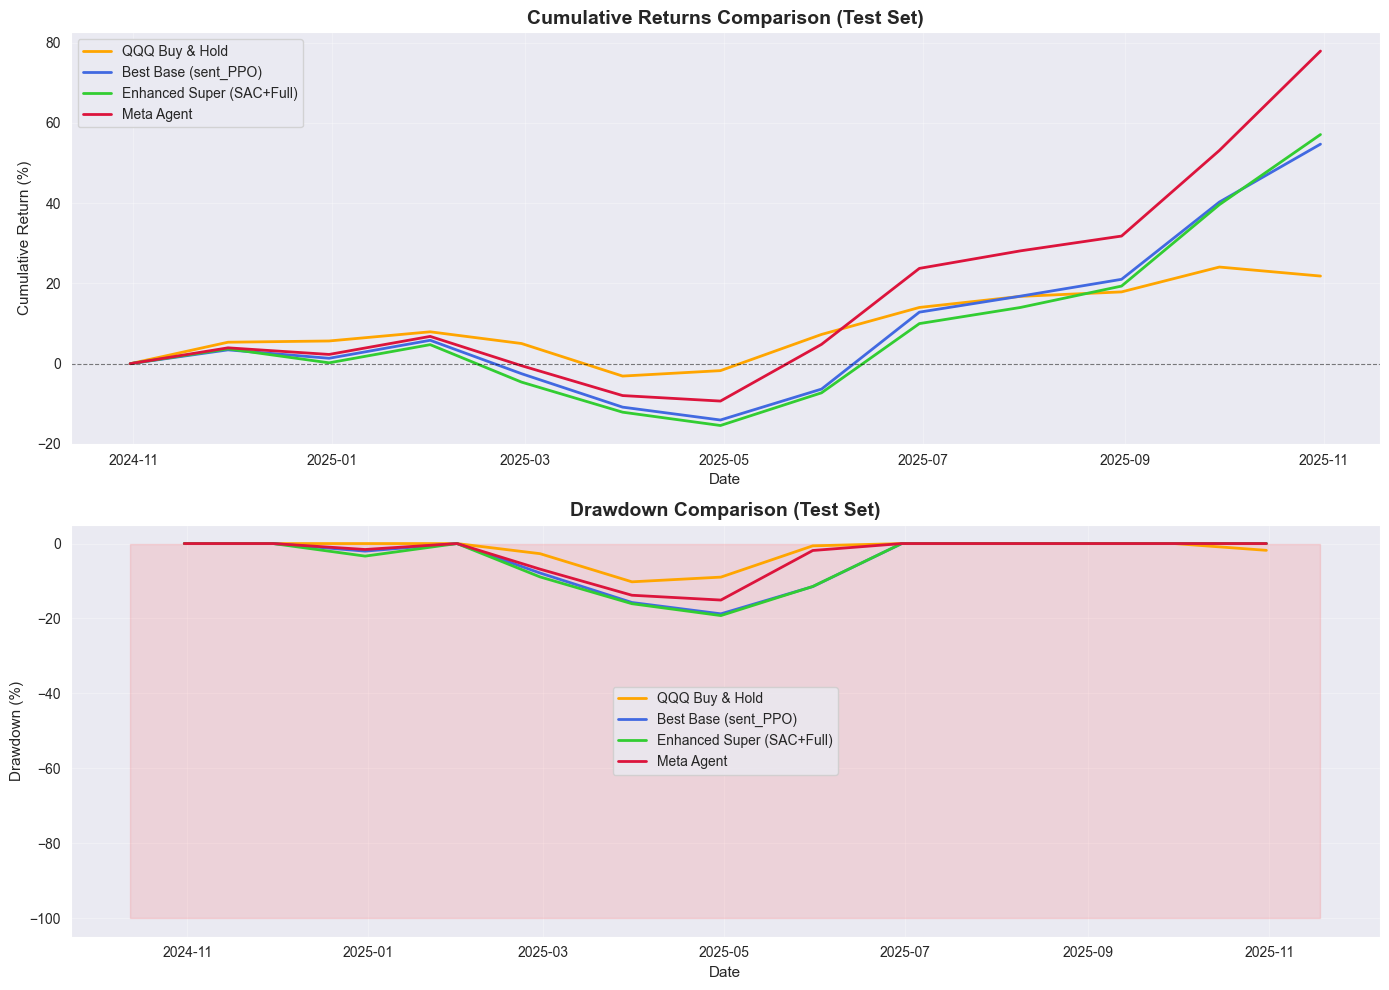


   Creating portfolio allocation plot...
Saved: results/portfolio_allocations.png


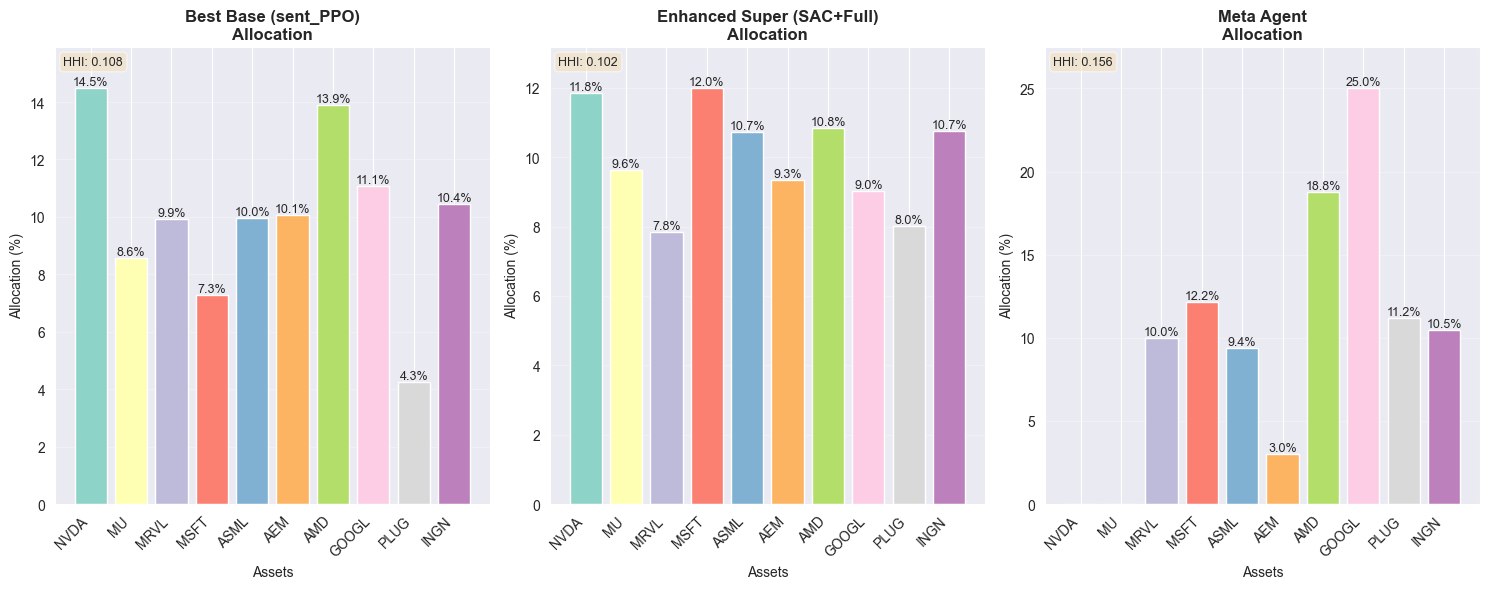

In [11]:
# Performance comparison plot
all_portfolio_histories = {
    'QQQ Buy & Hold': qqq_portfolio_history,
    'Best Base (sent_PPO)': best_base_portfolio_history,
    'Enhanced Super (SAC+Full)': super_portfolio_history,
    'Meta Agent': meta_portfolio_history
}

plot_performance_comparison(test_prices, all_portfolio_histories, 
                            qqq_benchmark=test_qqq,
                            save_path='results/performance_comparison.png')

# Portfolio allocation plot
all_final_weights = {
    'Best Base (sent_PPO)': best_base_final_weights,
    'Enhanced Super (SAC+Full)': super_final_weights,
    'Meta Agent': meta_final_weights
}

asset_names = list(test_prices.columns)
plot_portfolio_allocations(all_final_weights, asset_names,
                            save_path='results/portfolio_allocations.png')


In [12]:

print("Saving files...")

print("\n✓ Models:")
print("  - models/super_agent_sac_best.zip")
print("  - models/meta_agent_best.zip")
print("\n✓ Results:")
print("  - results/standard_split_results.json")
print("\n✓ Visualizations:")
print("  - results/performance_comparison.png")
print("  - results/portfolio_allocations.png")

print(f"\n{best_strategy} for best performance!")

Saving files...

✓ Models:
  - models/super_agent_sac_best.zip
  - models/meta_agent_best.zip

✓ Results:
  - results/standard_split_results.json

✓ Visualizations:
  - results/performance_comparison.png
  - results/portfolio_allocations.png

Meta for best performance!
